### **FASE 8: ANÁLISIS BIVARIADO**

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("FASE 8: ANÁLISIS BIVARIADO - ENDES ANEMIA 2024")

FASE 8: ANÁLISIS BIVARIADO - ENDES ANEMIA 2024


In [4]:
print("\n[1/6] Cargando datos...")

df = pd.read_csv('/content/drive/MyDrive/endes-anemia2024-data/processed/06_data_features_selected.csv')

print(f"✓ Datos cargados: {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"✓ Variable respuesta: anemia_nivel")


[1/6] Cargando datos...
✓ Datos cargados: 17,418 registros × 4 variables
✓ Variable respuesta: anemia_nivel


CORRELACIÓN CONTINUAS (SPEARMAN)

In [5]:
print("\n[2/6] ANÁLISIS BIVARIADO - VARIABLES CONTINUAS")
print("-"*70)
print("\nMétodo: Correlación Spearman")
print("Interpretación: Si p < 0.05, existe asociación significativa\n")

continuas = ['edad_nino', 'edad_madre']
resultados_continuas = []

print(f"{'Variable':<20s} | {'r (Spearman)':<15s} | {'p-value':<12s} | Significancia")
print("-"*70)

for var in continuas:
    if var in df.columns and 'anemia_nivel' in df.columns:
        corr, pval = spearmanr(df[var], df['anemia_nivel'])

        # Determinar significancia
        if pval < 0.001:
            sig = "*** ALTAMENTE significativo (p < 0.001)"
        elif pval < 0.01:
            sig = "** MUY significativo (p < 0.01)"
        elif pval < 0.05:
            sig = "* Significativo (p < 0.05)"
        else:
            sig = "ns NO significativo (p ≥ 0.05)"

        print(f"{var:<20s} | {corr:>14.4f} | {pval:>11.2e} | {sig}")
        resultados_continuas.append({
            'Variable': var,
            'Correlacion': corr,
            'p_value': pval,
            'Significancia': sig
        })


[2/6] ANÁLISIS BIVARIADO - VARIABLES CONTINUAS
----------------------------------------------------------------------

Método: Correlación Spearman
Interpretación: Si p < 0.05, existe asociación significativa

Variable             | r (Spearman)    | p-value      | Significancia
----------------------------------------------------------------------
edad_nino            |         0.3324 |    0.00e+00 | *** ALTAMENTE significativo (p < 0.001)
edad_madre           |         0.0968 |    1.44e-37 | *** ALTAMENTE significativo (p < 0.001)



[3/6] Generando GRÁFICO 1: Boxplot - Variables Continuas vs Anemia...


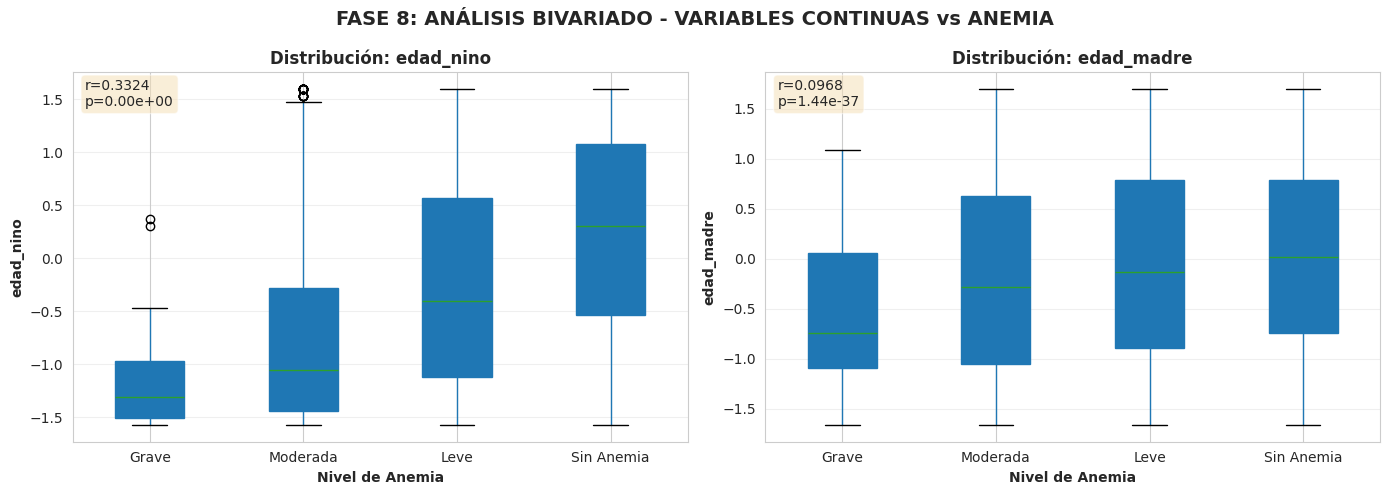

✓ Gráfico 1 completado


In [13]:
print("\n[3/6] Generando GRÁFICO 1: Boxplot - Variables Continuas vs Anemia...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FASE 8: VARIABLES CONTINUAS vs ANEMIA',
             fontsize=14, fontweight='bold')

for idx, var in enumerate(continuas):
    ax = axes[idx]

    # Crear boxplot por categoría de anemia
    df.boxplot(column=var, by='anemia_nivel', ax=ax, patch_artist=True)

    ax.set_xlabel('Nivel de Anemia', fontweight='bold')
    ax.set_ylabel(var, fontweight='bold')
    ax.set_title(f'Distribución: {var}', fontweight='bold')
    ax.set_xticklabels(['Grave', 'Moderada', 'Leve', 'Sin Anemia'])
    ax.grid(True, alpha=0.3, axis='y')

    # Agregar correlación
    corr, pval = spearmanr(df[var], df['anemia_nivel'])
    ax.text(0.02, 0.98, f'r={corr:.4f}\np={pval:.2e}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('')  # Remover título duplicado de boxplot
fig.suptitle('FASE 8: ANÁLISIS BIVARIADO - VARIABLES CONTINUAS vs ANEMIA',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Gráfico 1 completado")


[4/5] Generando GRÁFICO 2: Scatter Plot con Anemia...


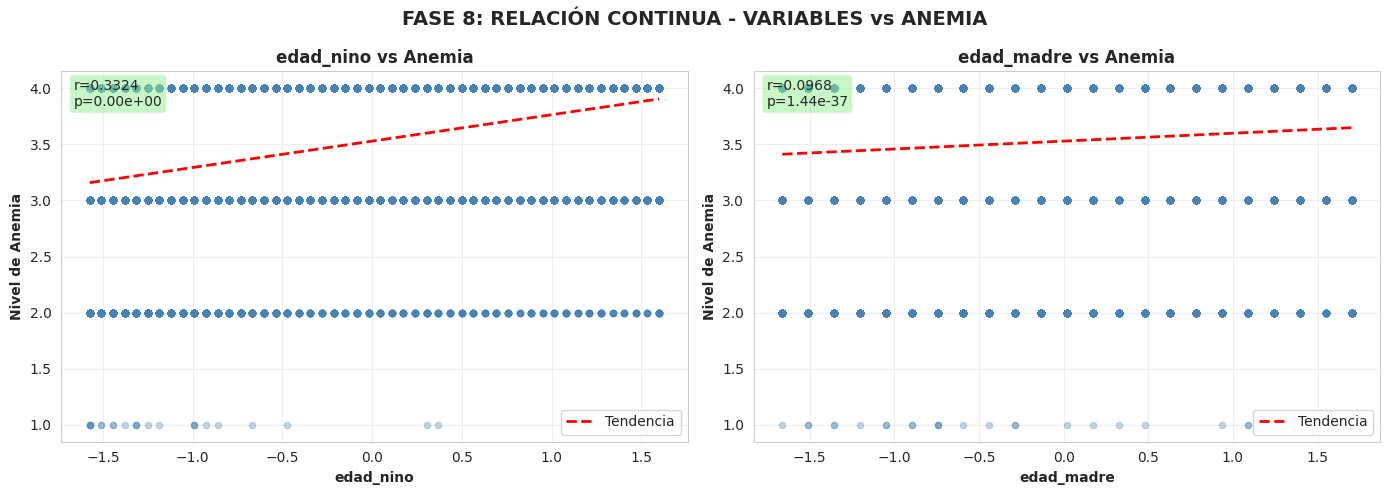

In [14]:
print("\n[4/5] Generando GRÁFICO 2: Scatter Plot con Anemia...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FASE 8: RELACIÓN CONTINUA - VARIABLES vs ANEMIA',
             fontsize=14, fontweight='bold')

for idx, var in enumerate(continuas):
    ax = axes[idx]

    # Scatter plot con transparencia
    ax.scatter(df[var], df['anemia_nivel'], alpha=0.3, s=20, color='steelblue')

    # Agregar línea de tendencia
    z = np.polyfit(df[var], df['anemia_nivel'], 1)
    p = np.poly1d(z)
    ax.plot(df[var].sort_values(), p(df[var].sort_values()), "r--", linewidth=2, label='Tendencia')

    ax.set_xlabel(var, fontweight='bold')
    ax.set_ylabel('Nivel de Anemia', fontweight='bold')
    ax.set_title(f'{var} vs Anemia', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Agregar correlación
    corr, pval = spearmanr(df[var], df['anemia_nivel'])
    ax.text(0.02, 0.98, f'r={corr:.4f}\np={pval:.2e}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()